In [3]:
from statistics import linear_regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

uber_data = pd.read_csv('uber.csv')
uber_data.head()

,city_id,period_start,wait_time,treat,commute,trips_pool,trips_express,rider_cancellations,total_driver_payout,total_matches,total_double_matches
0,Boston,2018-02-19 7.00,2 mins,False,True,1415,3245,256,34458.41163,3372,1476
1,Boston,2018-02-19 9.40,5 mins,True,False,1461,2363,203,29764.34982,2288,1275
2,Boston,2018-02-19 12.20,2 mins,False,False,1362,2184,118,27437.36736,2283,962
3,Boston,2018-02-19 15.00,5 mins,True,True,1984,3584,355,44995.45299,4035,2021
4,Boston,2018-02-19 17.40,2 mins,False,False,1371,2580,181,27583.95530,2200,979


In [4]:
data = uber_data.drop(columns=['city_id', 'wait_time'])
data.head()

,period_start,treat,commute,trips_pool,trips_express,rider_cancellations,total_driver_payout,total_matches,total_double_matches
0,2018-02-19 7.00,False,True,1415,3245,256,34458.41163,3372,1476
1,2018-02-19 9.40,True,False,1461,2363,203,29764.34982,2288,1275
2,2018-02-19 12.20,False,False,1362,2184,118,27437.36736,2283,962
3,2018-02-19 15.00,True,True,1984,3584,355,44995.45299,4035,2021
4,2018-02-19 17.40,False,False,1371,2580,181,27583.95530,2200,979


In [5]:
#   The effect of longer wait times on the number of Express trips taken using linear regression.

linear_regression(data['treat'], data['trips_express'])

LinearRegression(slope=-192.28571428571428, intercept=2611.666666666667)

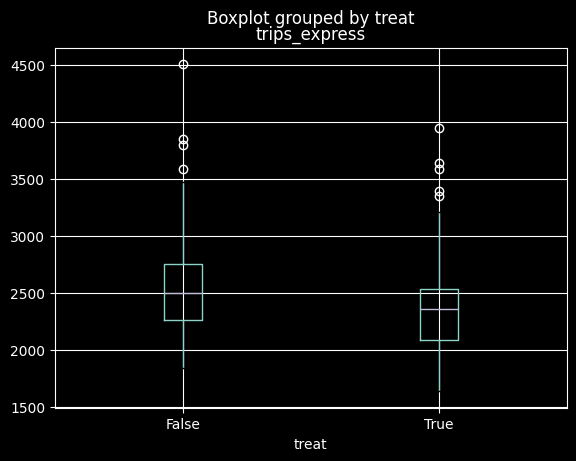

In [6]:
# Visualization
data.boxplot(column='trips_express', by='treat')

plt.style.use("default")
plt.show()

In [7]:
#   The effect of longer wait times on the number of POOL trips taken using linear regression

model = smf.ols('trips_pool ~ treat', data = data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             trips_pool   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     5.445
Date:                Thu, 05 Mar 2026   Prob (F-statistic):             0.0212
Time:                        15:44:55   Log-Likelihood:                -875.22
No. Observations:                 126   AIC:                             1754.
Df Residuals:                     124   BIC:                             1760.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1355.3175     31.933     42.442

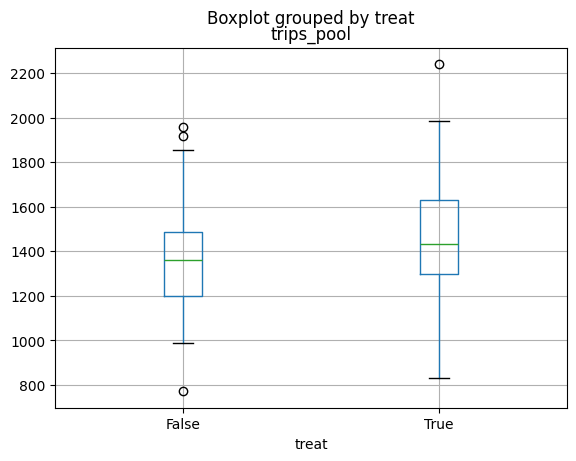

In [8]:
#   Visualization
data.boxplot(column='trips_pool', by='treat')
plt.style.use("ggplot")
plt.show()

In [9]:
#   Let's add a column to sum total trips (pool + express)
data['total_trips'] = (data['trips_pool'] + data['trips_express'])
data.head()

,period_start,treat,commute,trips_pool,trips_express,rider_cancellations,total_driver_payout,total_matches,total_double_matches,total_trips
0,2018-02-19 7.00,False,True,1415,3245,256,34458.41163,3372,1476,4660
1,2018-02-19 9.40,True,False,1461,2363,203,29764.34982,2288,1275,3824
2,2018-02-19 12.20,False,False,1362,2184,118,27437.36736,2283,962,3546
3,2018-02-19 15.00,True,True,1984,3584,355,44995.45299,4035,2021,5568
4,2018-02-19 17.40,False,False,1371,2580,181,27583.95530,2200,979,3951


In [10]:
# The effect of longer wait times on the number of total trips (Express + POOL) using linear regression.
linear_regression(data['treat'], data['total_trips'])

LinearRegression(slope=-86.9047619047619, intercept=3966.9841269841268)

In [11]:
#   The effect of longer wait times on the rider cancellations with linear regression.
cancel_lin_reg = linear_regression(data['treat'], data['rider_cancellations'])
cancel_lin_reg

LinearRegression(slope=24.77777777777778, intercept=165.34920634920636)

In [12]:
#   By what percentage do rider cancellations change due to longer wait times?
intercept = cancel_lin_reg.intercept
slope = cancel_lin_reg.slope

percentile_change = (((intercept + slope) / intercept) - 1) * 100

percentile_change

14.985120476144754

In [13]:
# New colum, 'driver_payout_per_ride'
data['driver_payout_per_ride'] = (data['total_driver_payout'] / data['total_trips'])
data.head()

,period_start,treat,commute,trips_pool,trips_express,rider_cancellations,total_driver_payout,total_matches,total_double_matches,total_trips,driver_payout_per_ride
0,2018-02-19 7.00,False,True,1415,3245,256,34458.41163,3372,1476,4660,7.394509
1,2018-02-19 9.40,True,False,1461,2363,203,29764.34982,2288,1275,3824,7.783564
2,2018-02-19 12.20,False,False,1362,2184,118,27437.36736,2283,962,3546,7.737554
3,2018-02-19 15.00,True,True,1984,3584,355,44995.45299,4035,2021,5568,8.081080
4,2018-02-19 17.40,False,False,1371,2580,181,27583.95530,2200,979,3951,6.981512


In [22]:
#   The effect of longer wait times on the driver payout per ride with linear regression.
payout_lin_reg = linear_regression(data['treat'], data['driver_payout_per_ride'])
payout_lin_reg

LinearRegression(slope=-0.37740851413909426, intercept=7.364866218570769)

In [15]:
model2 = smf.ols('driver_payout_per_ride ~ treat', data = data).fit()
print(model2.summary())

                              OLS Regression Results                              
Dep. Variable:     driver_payout_per_ride   R-squared:                       0.088
Model:                                OLS   Adj. R-squared:                  0.081
Method:                     Least Squares   F-statistic:                     11.99
Date:                    Thu, 05 Mar 2026   Prob (F-statistic):           0.000736
Time:                            15:44:56   Log-Likelihood:                -115.87
No. Observations:                     126   AIC:                             235.7
Df Residuals:                         124   BIC:                             241.4
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Interc

In [16]:
#   The effect of longer wait times on total driver payouts with linear regression.
linear_regression(data['treat'], data['total_driver_payout'])

LinearRegression(slope=-2108.0365320634924, intercept=29291.238921428572)

In [17]:
#   The effect of longer wait times on total matches by using linear regression. Consider statistical significance from model summary.
model3 = smf.ols('total_matches ~ treat', data = data).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:          total_matches   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     3.301
Date:                Thu, 05 Mar 2026   Prob (F-statistic):             0.0716
Time:                        15:44:56   Log-Likelihood:                -984.22
No. Observations:                 126   AIC:                             1972.
Df Residuals:                     124   BIC:                             1978.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2633.2063     75.852     34.715

In [18]:
#   The effect of longer waiting times on double matches by using linear regression. Consider statistical significance from model summary.

model4 = smf.ols('total_double_matches ~ treat', data = data).fit()
print(model4.summary())

                             OLS Regression Results                             
Dep. Variable:     total_double_matches   R-squared:                       0.010
Model:                              OLS   Adj. R-squared:                  0.002
Method:                   Least Squares   F-statistic:                     1.281
Date:                  Thu, 05 Mar 2026   Prob (F-statistic):              0.260
Time:                          15:44:56   Log-Likelihood:                -915.85
No. Observations:                   126   AIC:                             1836.
Df Residuals:                       124   BIC:                             1841.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1287.1587  

In [19]:
#   The effect of longer wait times on the number of total trips using linear regression. What is the effect of longer wait times on number of total trips?
model5 = smf.ols('total_trips ~ treat', data = data).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:            total_trips   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.7214
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.397
Time:                        15:44:56   Log-Likelihood:                -978.27
No. Observations:                 126   AIC:                             1961.
Df Residuals:                     124   BIC:                             1966.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      3966.9841     72.350     54.830

In [21]:
#   The effect of longer wait times on rider cancellations using linear regression. What is the effect of longer wait times on number of total trips?
model5 = smf.ols('rider_cancellations ~ treat', data = data).fit()
print(model5.summary())

                             OLS Regression Results                            
Dep. Variable:     rider_cancellations   R-squared:                       0.058
Model:                             OLS   Adj. R-squared:                  0.050
Method:                  Least Squares   F-statistic:                     7.640
Date:                 Thu, 05 Mar 2026   Prob (F-statistic):            0.00658
Time:                         15:46:49   Log-Likelihood:                -671.48
No. Observations:                  126   AIC:                             1347.
Df Residuals:                      124   BIC:                             1353.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       165.3492      6.339 

In [23]:
#   By what percentage driver payouts change due to longer wait times?
payout_intercept = payout_lin_reg.intercept
payout_slope = payout_lin_reg.slope

percentile_change2 = (((payout_intercept + payout_slope) / payout_intercept) - 1) * 100

percentile_change2

-5.124444938150341